### Importing libraries for the project

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk import word_tokenize, sent_tokenize
import pickle

from wordcloud import WordCloud
from preprocessing_utils import preprocessing, preprocess_series  # shared cleaning logic

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    classification_report, roc_auc_score, roc_curve, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

import optuna
import warnings
warnings.filterwarnings('ignore')

### Loading the data

In [2]:
df = pd.read_csv(r'C:\Users\jitenshah\OneDrive\Desktop\Email_Spam_Project\dataset\emails.csv')

### Understanding the data

In [3]:
df.sample()

,text,spam
1103,"Subject: our goood medz hello , welcome to ph...",1


In [4]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(33)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.6 MB


### Cleaning the data

In [7]:
df = df.drop_duplicates(keep='first').reset_index(drop=True)

### Creating new features from text: number of characters, words, sentences

In [8]:
df['length'] = df['text'].apply(len)

In [9]:
df['word_count'] = df['text'].apply(lambda x: len(word_tokenize(x)))

In [10]:
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)))
df.sample()

,text,spam,length,word_count,sentence_count
3926,Subject: this summer ' s houston visits richa...,0,1676,401,18


### EDA — univariate analysis
#### spam column analysis

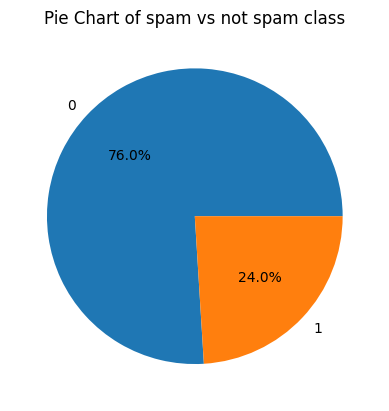

In [11]:
result = df['spam'].value_counts()
result.plot(kind='pie', autopct='%1.1f%%')
plt.title('Pie Chart of spam vs not spam class')
plt.show()


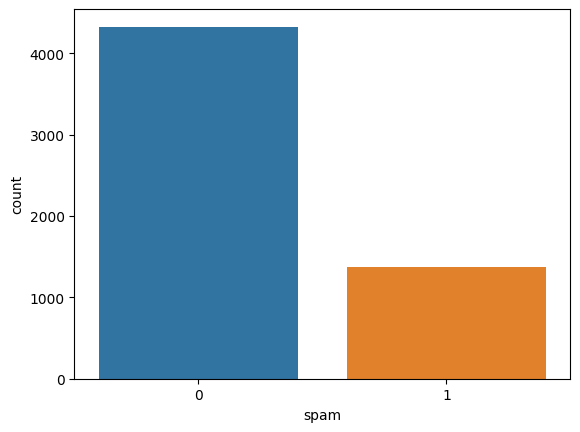

In [12]:
temp = result.reset_index()
sns.barplot(data=temp, x='spam', y='count', hue='spam', legend=False)
plt.show()


**Insight:**
* The spam column is imbalanced: roughly 76% not spam, 24% spam.
* This imbalance should be handled when building the model (e.g. `class_weight='balanced'`).

#### character / word / sentence column analysis

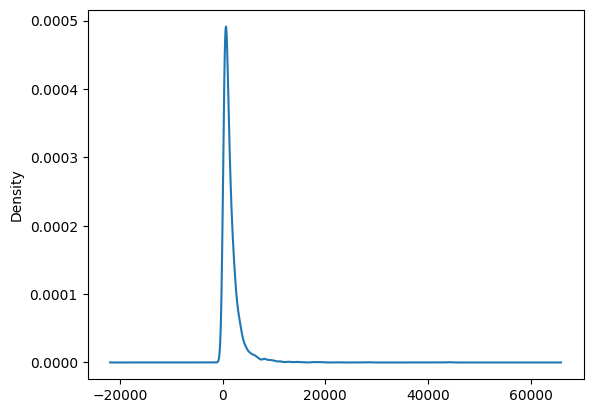

In [13]:
df['length'].plot(kind='kde')
plt.show()


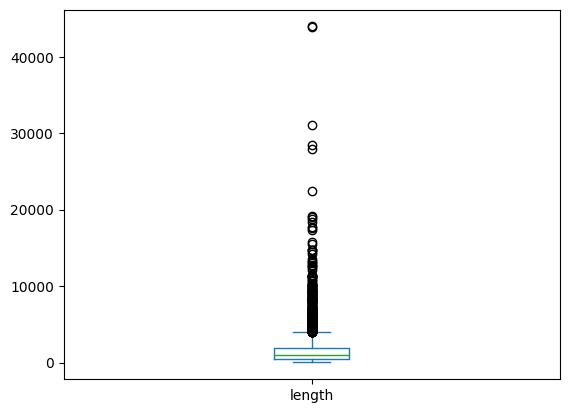

In [14]:
df['length'].plot(kind='box')
plt.show()


In [15]:
df['length'].skew()

np.float64(6.897665872603887)

**Insight:** 
* the data is not normally distributed and is highly positively skewed, with a lot of outliers.

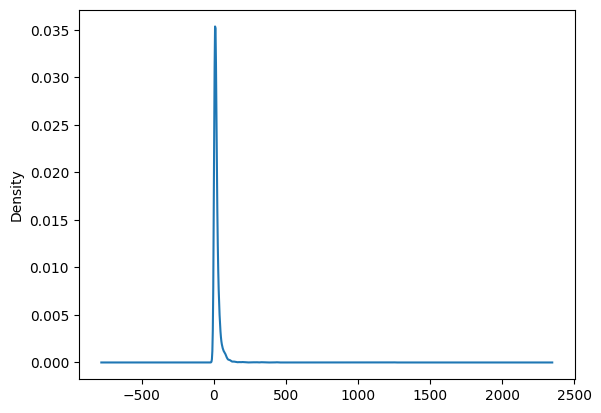

In [16]:
df['sentence_count'].plot(kind='kde')
plt.show()


In [17]:
df['sentence_count'].skew()

np.float64(22.933989167867345)

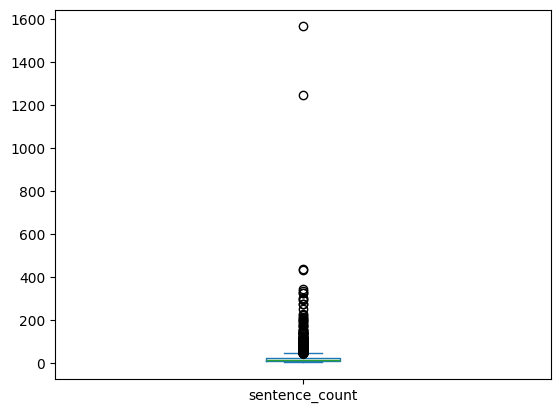

In [18]:
df['sentence_count'].plot(kind='box')
plt.show()


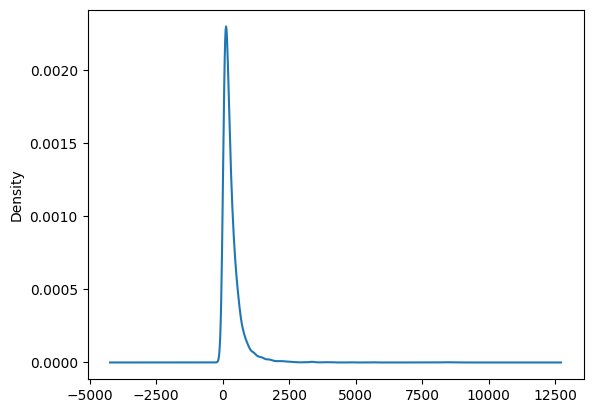

In [19]:
df['word_count'].plot(kind='kde')
plt.show()


In [20]:
df['word_count'].skew()

np.float64(6.422737635034371)

### Bivariate analysis

In [21]:
print("Not Spam text message detail!")
df[df['spam'] == 0][['length', 'word_count', 'sentence_count']].describe()


Not Spam text message detail!


,length,word_count,sentence_count
count,4327.000000,4327.000000,4327.000000
mean,1634.200139,347.283799,19.838225
std,1965.016383,407.227757,38.124564
min,13.000000,3.000000,1.000000
25%,577.500000,120.000000,7.000000
50%,1122.000000,240.000000,13.000000
75%,2037.500000,440.500000,22.000000
max,43952.000000,8479.000000,1565.000000


In [22]:
print("Spam text message detail!")
df[df['spam'] == 1][['length', 'word_count', 'sentence_count']].describe()


Spam text message detail!


,length,word_count,sentence_count
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,267.896199,18.274123
std,2271.372893,451.623124,28.130434
min,18.000000,5.000000,1.000000
25%,401.500000,80.000000,6.000000
50%,693.500000,141.000000,11.000000
75%,1250.250000,252.000000,18.000000
max,28432.000000,6131.000000,438.000000


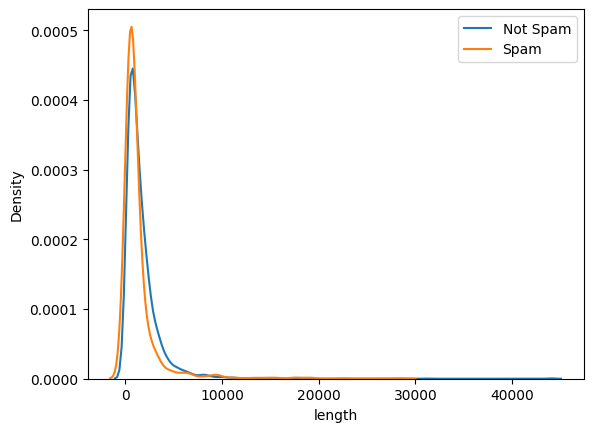

In [23]:
sns.kdeplot(df[df['spam'] == 0]['length'], label='Not Spam')
sns.kdeplot(df[df['spam'] == 1]['length'], label='Spam')
plt.legend()
plt.show()


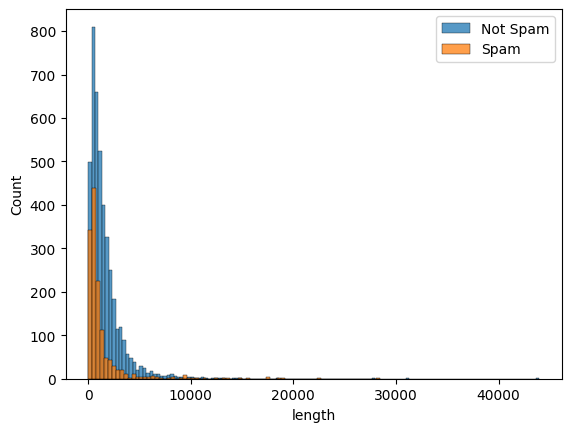

In [24]:
sns.histplot(df[df['spam'] == 0]['length'], label='Not Spam')
sns.histplot(df[df['spam'] == 1]['length'], label='Spam')
plt.legend()
plt.show()


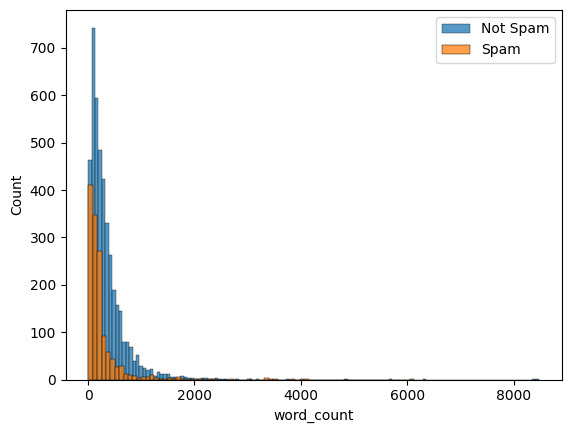

In [25]:
sns.histplot(df[df['spam'] == 0]['word_count'], label='Not Spam')
sns.histplot(df[df['spam'] == 1]['word_count'], label='Spam')
plt.legend()
plt.show()


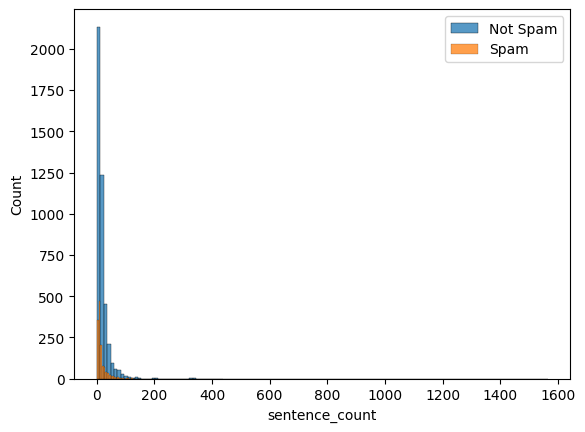

In [26]:
sns.histplot(df[df['spam'] == 0]['sentence_count'], label='Not Spam')
sns.histplot(df[df['spam'] == 1]['sentence_count'], label='Spam')
plt.legend()
plt.show()


### Multivariate analysis

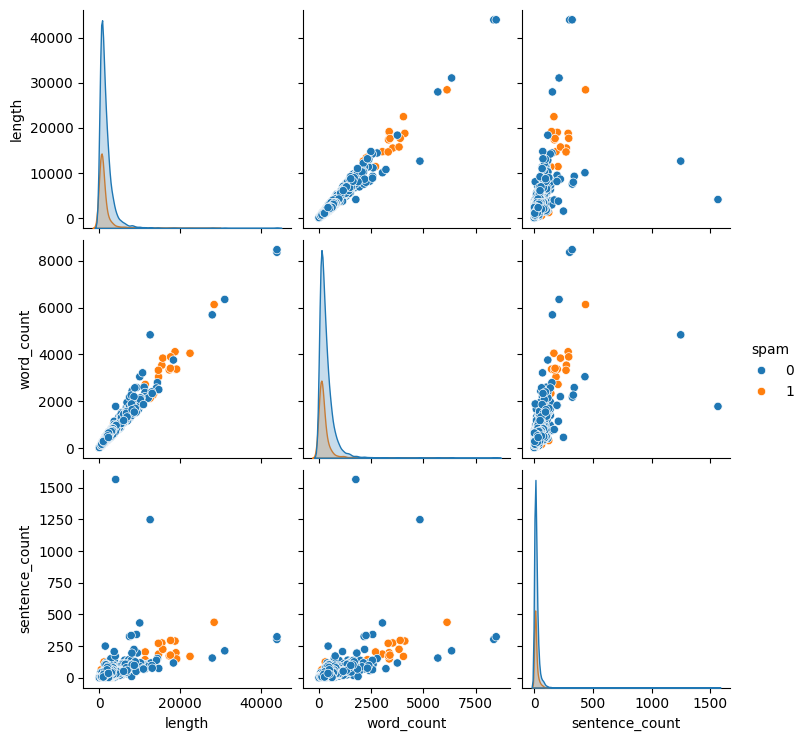

In [27]:
sns.pairplot(data=df, hue='spam')
plt.show()


In [28]:
from scipy.stats import pointbiserialr
corr_char, p1 = pointbiserialr(df['length'], df['spam'])
corr_words, p2 = pointbiserialr(df['word_count'], df['spam'])
corr_sent, p3 = pointbiserialr(df['sentence_count'], df['spam'])
corr_char, corr_words, corr_sent


(np.float64(-0.0661496100710989),
 np.float64(-0.08082430278026788),
 np.float64(-0.01857209226097521))

### Text preprocessing

In [29]:
df['transformed_text'] = df['text'].apply(preprocessing)

### Word clouds & most common words (EDA only)

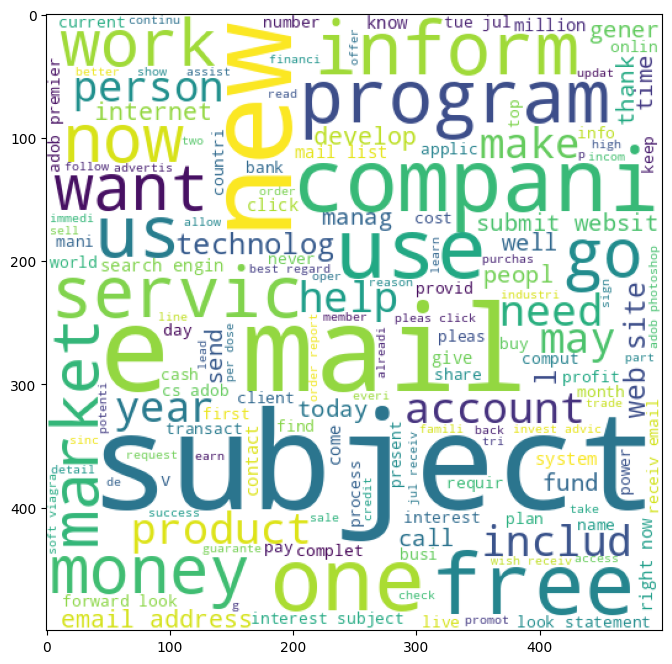

In [30]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc = wc.generate(df[df['spam'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12, 8))
plt.imshow(spam_wc)
plt.show()


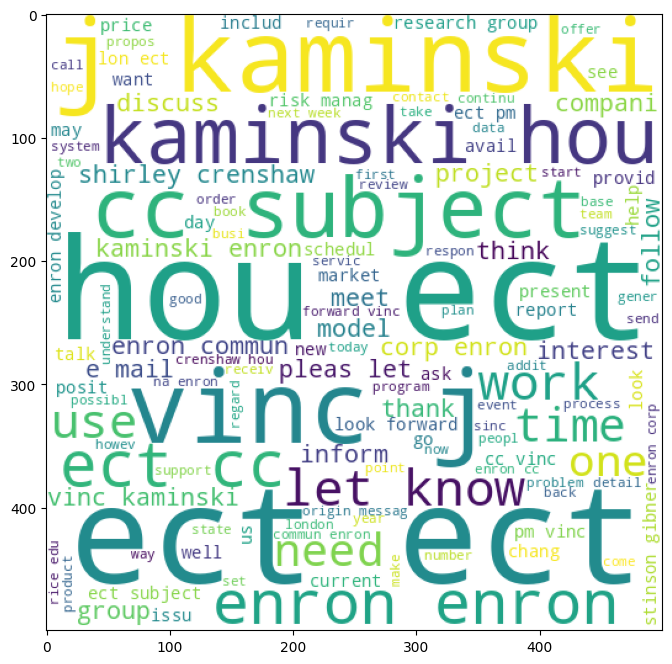

In [31]:
notspam_wc = wc.generate(df[df['spam'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12, 8))
plt.imshow(notspam_wc)
plt.show()


In [32]:
spam_words = []
for msg in df[df['spam'] == 1]['transformed_text']:
    spam_words.extend(msg.split())
len(spam_words)


175660

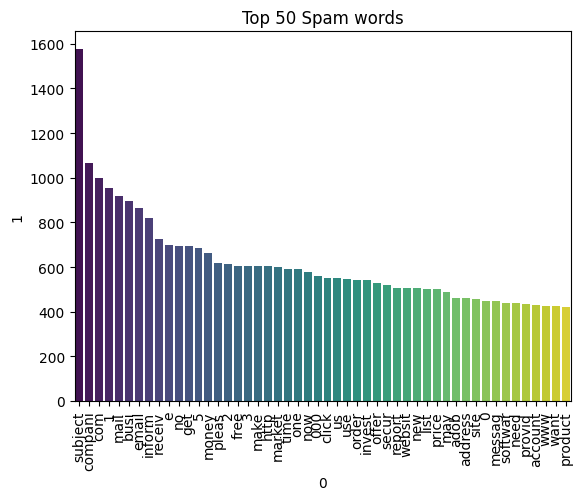

In [33]:
spam_data = pd.DataFrame(Counter(spam_words).most_common(50))
sns.barplot(data=spam_data, x=0, y=1, palette='viridis')
plt.title("Top 50 Spam words")
plt.xticks(rotation='vertical')
plt.show()


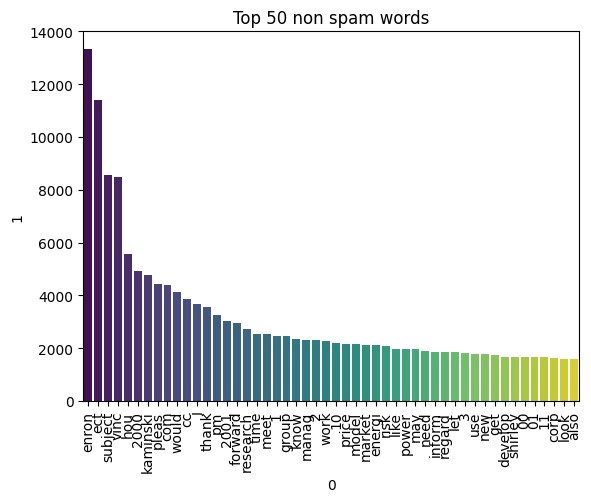

In [34]:
notspam_words = []
for msg in df[df['spam'] == 0]['transformed_text']:
    notspam_words.extend(msg.split())

notspam_data = pd.DataFrame(Counter(notspam_words).most_common(50))
sns.barplot(data=notspam_data, x=0, y=1, palette='viridis')
plt.title("Top 50 non spam words")
plt.xticks(rotation='vertical')
plt.show()


### Exploratory model comparison (on pre-cleaned text)

This section is only for **comparing model families and picking hyperparameters**.
It uses the already-cleaned `transformed_text` column with a standalone
`CountVectorizer`. This is fine as an exploration step — the final production
pipeline (built later) is trained separately on raw text.

In [35]:
X_explore = df['transformed_text']
y = df['spam']

x_train_e, x_test_e, y_train, y_test = train_test_split(
    X_explore, y, test_size=0.2, stratify=y, random_state=42
)

cv_explore = CountVectorizer(max_features=5000, min_df=5)
x_train_encode = cv_explore.fit_transform(x_train_e)
x_test_encode = cv_explore.transform(x_test_e)
x_train_encode.shape


(4556, 5000)

In [36]:
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "SVC": SVC(),
    "GradientBoosting": GradientBoostingClassifier()
}

result = []
for name, model in models.items():
    model.fit(x_train_encode, y_train)
    y_pred = model.predict(x_test_encode)
    result.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    })

pd.DataFrame(result).sort_values(by='f1', ascending=False)


,model,accuracy,precision,recall,f1
1,LogisticRegression,0.992098,0.985348,0.981752,0.983547
3,RandomForest,0.990342,0.981685,0.978102,0.979890
0,MultinomialNB,0.985075,0.947735,0.992701,0.969697
4,SVC,0.980685,0.984615,0.934307,0.958801
5,GradientBoosting,0.976295,0.966038,0.934307,0.949907
2,DecisionTree,0.957858,0.915441,0.908759,0.912088


### Hyperparameter tuning with Optuna

In [37]:
def objective(trial):
    C = trial.suggest_float("C", 1e-3, 100, log=True)
    solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    model = LogisticRegression(C=C, solver=solver, class_weight=class_weight, max_iter=1000)
    score = cross_val_score(model, x_train_encode, y_train, cv=5, scoring="f1", n_jobs=-1).mean()
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)


[I 2026-07-19 14:15:15,587] A new study created in memory with name: no-name-75ec20d5-775d-4e6e-a7e8-d14a2a84c791
[I 2026-07-19 14:15:23,238] Trial 0 finished with value: 0.9735019762166945 and parameters: {'C': 0.07923373031870833, 'solver': 'liblinear', 'class_weight': None}. Best is trial 0 with value: 0.9735019762166945.
[I 2026-07-19 14:15:28,480] Trial 1 finished with value: 0.8936848931033328 and parameters: {'C': 0.0021204806405668046, 'solver': 'lbfgs', 'class_weight': None}. Best is trial 0 with value: 0.9735019762166945.
[I 2026-07-19 14:15:33,405] Trial 2 finished with value: 0.9726438818448477 and parameters: {'C': 0.16995618225534811, 'solver': 'lbfgs', 'class_weight': None}. Best is trial 0 with value: 0.9735019762166945.
[I 2026-07-19 14:15:33,899] Trial 3 finished with value: 0.9683039144428699 and parameters: {'C': 0.242528349699697, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9735019762166945.
[I 2026-07-19 14:15:34,161] Trial 4 

In [38]:
study.best_value

0.9736069146508856

In [39]:
study.best_trial.params

{'C': 0.49059135001826176, 'solver': 'lbfgs', 'class_weight': None}

In [40]:
lr = LogisticRegression(**study.best_trial.params, max_iter=1000)
lr.fit(x_train_encode, y_train)


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.49059135001826176
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization probl

In [41]:
y_pred = lr.predict(x_test_encode)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       865
           1       0.98      0.99      0.98       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139



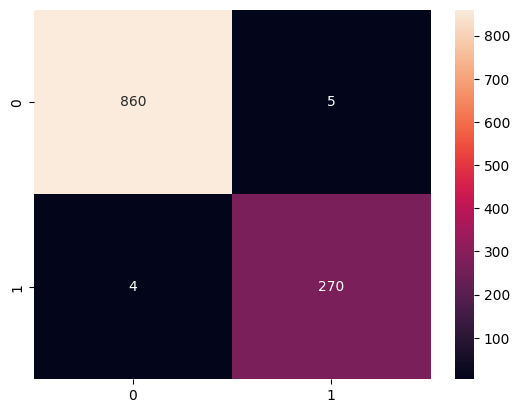

In [42]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()


In [43]:
y_prob = lr.predict_proba(x_test_encode)[:, 1]
roc_auc_score(y_test, y_prob)

0.9977595882030293

In [44]:
def objective(trial):
    max_depth = trial.suggest_categorical('Max_depth', [None, 50, 100, 200])
    max_samples = trial.suggest_categorical('max_samples', [0.5, 0.75, 1])
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10, 15])
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 5, 10, 15])
    class_weight = trial.suggest_categorical('class_weight', [None, "balanced"])

    model = RandomForestClassifier(
        max_depth=max_depth,
        max_samples=max_samples,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight
    )

    score = cross_val_score(model, x_train_encode, y_train, cv=5, scoring='f1').mean()
    return score


In [45]:
study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=30)

[I 2026-07-19 14:15:47,214] A new study created in memory with name: no-name-717a68e9-a901-4b0a-b69b-56bd707f5f63
[I 2026-07-19 14:15:52,447] Trial 0 finished with value: 0.9503413768507656 and parameters: {'Max_depth': 200, 'max_samples': 0.75, 'min_samples_split': 15, 'min_samples_leaf': 5, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9503413768507656.
[I 2026-07-19 14:15:55,151] Trial 1 finished with value: 0.8566669478802547 and parameters: {'Max_depth': 50, 'max_samples': 0.75, 'min_samples_split': 2, 'min_samples_leaf': 15, 'class_weight': None}. Best is trial 0 with value: 0.9503413768507656.
[I 2026-07-19 14:15:58,599] Trial 2 finished with value: 0.9225421501258483 and parameters: {'Max_depth': 50, 'max_samples': 0.75, 'min_samples_split': 2, 'min_samples_leaf': 10, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9503413768507656.
[I 2026-07-19 14:16:01,013] Trial 3 finished with value: 0.8833378383548164 and parameters: {'Max_depth': 50, 'max_samples'

In [46]:
study.best_trial.params

{'Max_depth': 100,
 'max_samples': 0.75,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'class_weight': None}

In [47]:
study.best_value

0.970642919744266

In [48]:
rf=RandomForestClassifier(max_depth=200,max_samples=0.75)

In [49]:
rf.fit(x_train_encode,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",200
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.75
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number

In [50]:
y_pred=rf.predict(x_test_encode)

In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       865
           1       0.98      0.97      0.98       274

    accuracy                           0.99      1139
   macro avg       0.99      0.98      0.98      1139
weighted avg       0.99      0.99      0.99      1139



In [52]:
precision_score(y_test,y_pred)

0.981549815498155

In [53]:
result=confusion_matrix(y_test,y_pred)

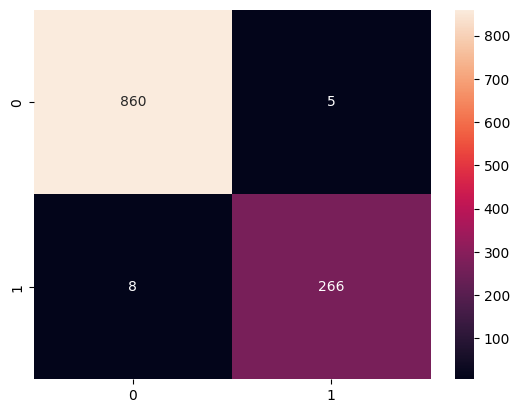

In [54]:
sns.heatmap(result,annot=True,fmt='d')
plt.show()

In [55]:
y_prob = lr.predict_proba(x_test_encode)[:, 1]
roc_auc_score(y_test, y_prob)

0.9977595882030293

### Building the FINAL production pipeline (correct way)

**Key point:** the pipeline must be trained on the **raw** `text` column, not
`transformed_text`. The pipeline's own `preprocessing` step will do the cleaning.
If we trained it on already-cleaned text, the pipeline would clean the text
*twice* during training but only *once* at real prediction time (when a user
types raw text in Streamlit) — a training/serving mismatch that can quietly hurt
accuracy and makes the vocabulary inconsistent.

In [56]:
# Raw, untouched text -- NOT df['transformed_text']
X_raw = df['text']
y = df['spam']

x_train, x_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)


In [57]:
pipe = Pipeline([
    ('preprocessing', FunctionTransformer(preprocess_series)),
    ('vectorizer', CountVectorizer(max_features=5000, min_df=5)),
    ('model', RandomForestClassifier(max_depth=200,max_samples=0.75))
])

pipe.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('vectorizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pre...0017766DFA0C0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True


In [58]:
y_pred = pipe.predict(x_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy : 0.9920983318700615
Precision: 0.9853479853479854
Recall   : 0.9817518248175182
F1       : 0.9835466179159049
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       865
           1       0.99      0.98      0.98       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139



In [59]:
# Sanity check: pipeline should handle a single raw, messy sentence end-to-end
sample = pd.Series(["Congratulations! You've WON a $1000 prize, click here NOW!!"])
pipe.predict(sample), pipe.predict_proba(sample)


(array([1]), array([[0.22, 0.78]]))

In [60]:
# Extra check: previously misclassified example (relied on the word "won",
# which used to be stripped out as a stopword before the fix above)
sample2 = pd.Series(["dear jiten congratulations you have won 10000 dollar and click the below link"])
pipe.predict(sample2), pipe.predict_proba(sample2)


(array([1]), array([[0.34, 0.66]]))

### Saving the final pipeline

In [61]:
with open('spam_pipeline.pkl', 'wb') as f:
    pickle.dump(pipe, f)

print("Pipeline saved to spam_pipeline.pkl")


Pipeline saved to spam_pipeline.pkl
